# Transfer Learning

**Transfer Learning** is a machine learning technique where a model trained on one task is reused for a different but related task. Instead of training a neural network from scratch, we start with a **pre-trained model** that has already learned useful features from a large dataset.

### Why Does Transfer Learning Work?

Early layers of CNNs learn **general features** such as:

- Edges
- Corners
- Shapes
- Colors
- Textures

Later layers learn task-specific features.



### The ImageNet Dataset

ImageNet contains:

- More than 14 million images
- Over 20,000 categories
- Approximately 1,000 commonly used classes for benchmarking

Examples include:

- Dogs
- Cats
- Birds
- Cars
- Flowers
- Fruits
- Buildings


In [1]:
# preliminaries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

dataset_path = tf.keras.utils.get_file(
    "flower_photos",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    untar=True
)

ModuleNotFoundError: No module named 'tensorflow'

In [22]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [23]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)
validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [24]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [25]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)


In [26]:
base_model.trainable = False


In [27]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation="softmax")  # 5 flower classes
])

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Epoch 1/5
92/92 [==============================] - 167s 2s/step - loss: 1.0909 - accuracy: 0.5518 - val_loss: 0.6247 - val_accuracy: 0.7916
Epoch 2/5
92/92 [==============================] - 137s 1s/step - loss: 0.6010 - accuracy: 0.7878 - val_loss: 0.4430 - val_accuracy: 0.8624
Epoch 3/5
92/92 [==============================] - 141s 2s/step - loss: 0.4985 - accuracy: 0.8178 - val_loss: 0.3846 - val_accuracy: 0.8638
Epoch 4/5
92/92 [==============================] - 139s 2s/step - loss: 0.4208 - accuracy: 0.8443 - val_loss: 0.3487 - val_accuracy: 0.8774
Epoch 5/5
23/23 [==============================] - 26s 1s/step - loss: 0.3324 - accuracy: 0.8856
Validation Accuracy: 0.8856


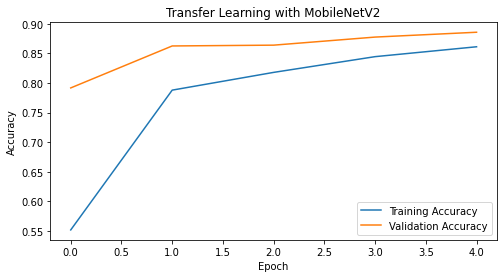

In [29]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)
loss, accuracy = model.evaluate(validation_dataset)
print(f"Validation Accuracy: {accuracy:.4f}")


plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning with MobileNetV2")
plt.legend()
plt.show()

### Lab Problems

---

1. Using the model from class, replace MobileNetV2 with ResNet50.

Evaluate:

- Training time
- Accuracy
- Model size

---

2. Create a transfer learning model using the TensorFlow Flowers dataset and classify five flower species.

### Lab Key*

1.

2.